In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random
import matplotlib.pyplot as plt
import seaborn as sns

**KAGGLE DATASET (REAL WORLD)**


In [2]:
real_df = pd.read_csv("/content/demand_forecasting_dataset (1) 2.csv")

In [3]:
real_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4921 entries, 0 to 4920
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              4921 non-null   object 
 1   product_id        4921 non-null   int64  
 2   category_id       4921 non-null   int64  
 3   store_id          4921 non-null   int64  
 4   historical_sales  4921 non-null   int64  
 5   price             4921 non-null   float64
 6   promotion_flag    4921 non-null   int64  
 7   holiday_flag      4921 non-null   int64  
 8   economic_index    4921 non-null   float64
 9   target_demand     4921 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 384.6+ KB


In [4]:
real_df.head()

,date,product_id,category_id,store_id,historical_sales,price,promotion_flag,holiday_flag,economic_index,target_demand
0,2022-01-02,1043,4,9,16,48.29,0,0,84.07,8
1,2022-01-02,1012,4,2,25,44.01,0,0,106.87,22
2,2022-01-03,1003,5,4,26,9.44,1,0,104.98,29
3,2022-01-03,1005,4,1,23,5.42,1,1,92.75,22
4,2022-01-04,1011,1,5,12,21.86,1,1,103.60,27


In [5]:
real_df['demand'] = real_df['target_demand']
real_df.drop('target_demand', axis=1, inplace=True)

In [6]:
real_df["holiday_flag"].value_counts()

,count
holiday_flag,
0,4171
1,750


In [7]:
real_df['price'].describe()

,price
count,4921.000000
mean,27.209683
std,12.923657
min,5.000000
25%,15.950000
50%,27.120000
75%,38.370000
max,49.990000


In [8]:
real_df.isnull().sum()

,0
date,0
product_id,0
category_id,0
store_id,0
historical_sales,0
price,0
promotion_flag,0
holiday_flag,0
economic_index,0
demand,0


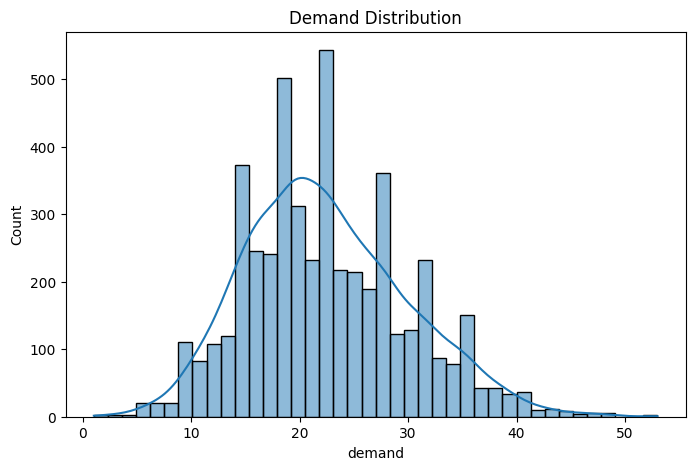

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(real_df['demand'], bins=40, kde=True)
plt.title("Demand Distribution")
plt.show()

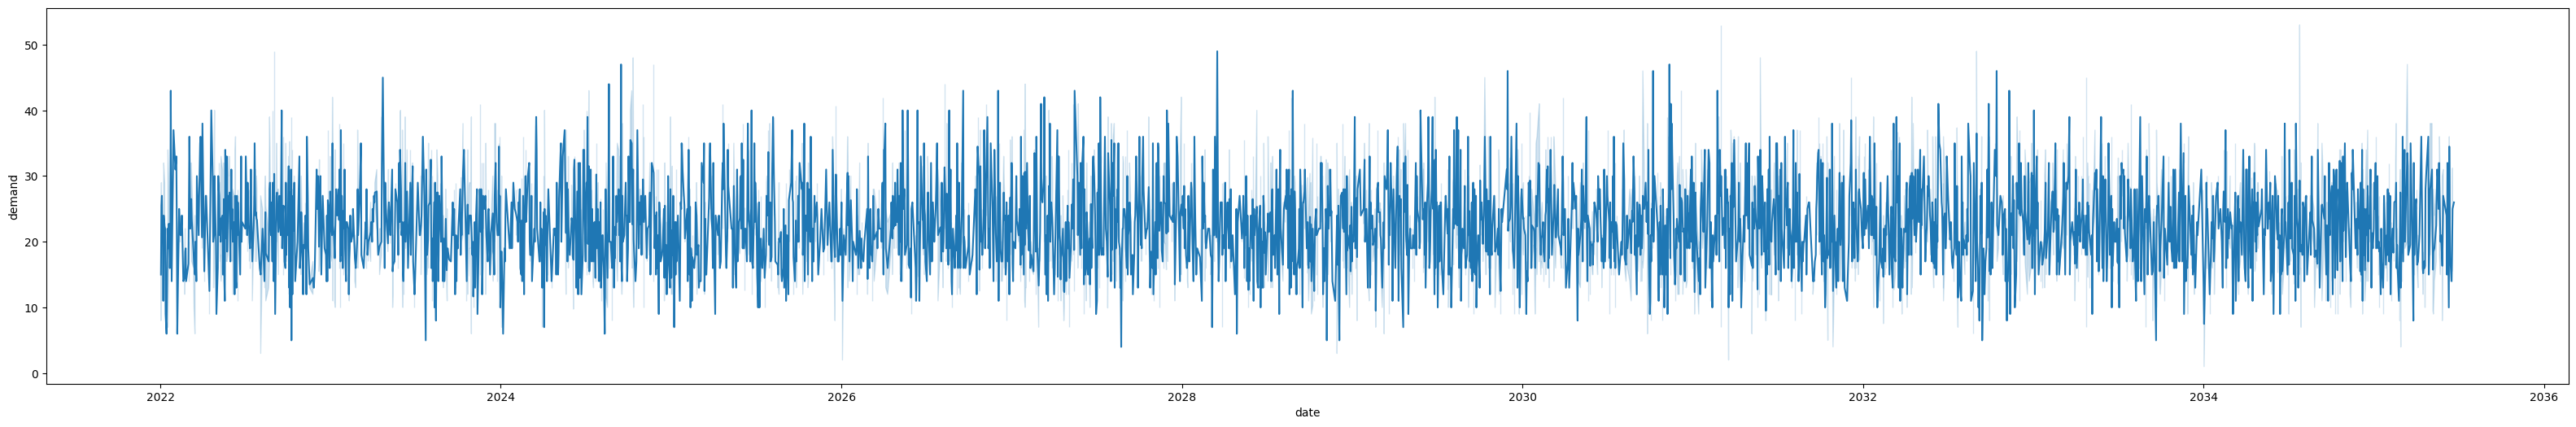

In [10]:
real_df['date'] = pd.to_datetime(real_df['date'])

plt.figure(figsize=(40, 6))

sns.lineplot(x='date', y='demand', data=real_df)
plt.show()

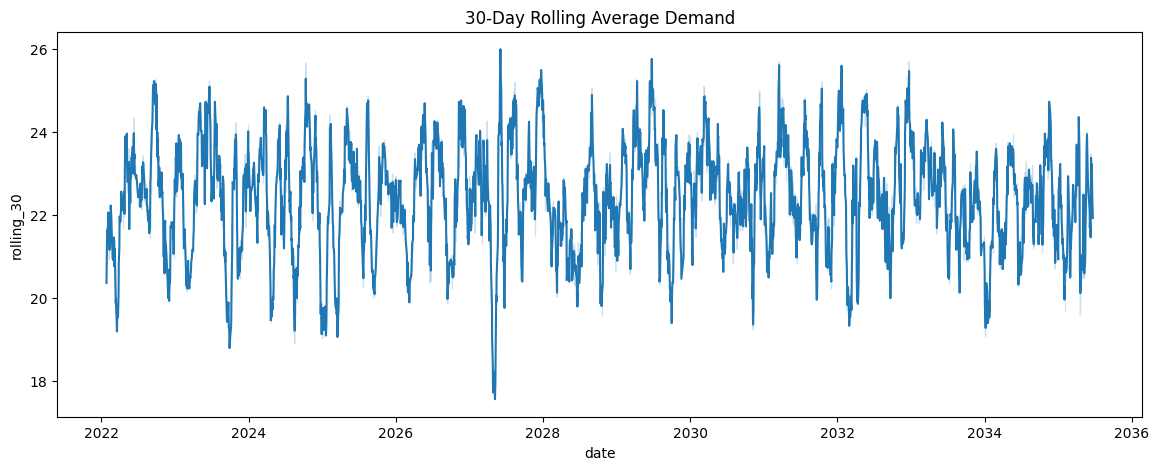

In [11]:
real_df['rolling_30'] = real_df['demand'].rolling(30).mean()

plt.figure(figsize=(14,5))
sns.lineplot(x='date', y='rolling_30', data=real_df)
plt.title("30-Day Rolling Average Demand")
plt.show()


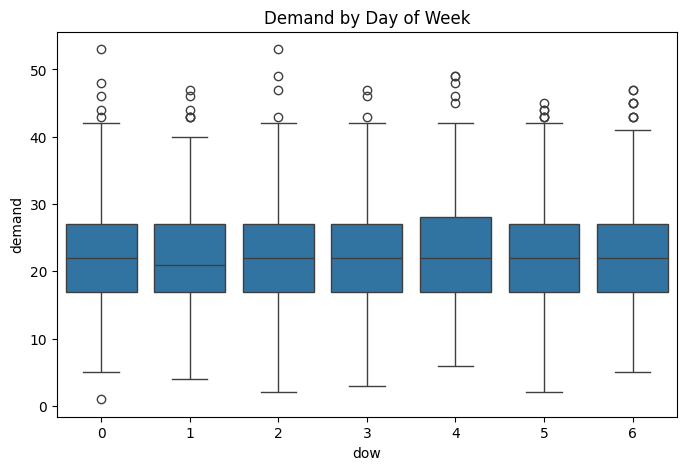

In [12]:
real_df['dow'] = real_df['date'].dt.dayofweek

plt.figure(figsize=(8,5))
sns.boxplot(x='dow', y='demand', data=real_df)
plt.title("Demand by Day of Week")
plt.show()

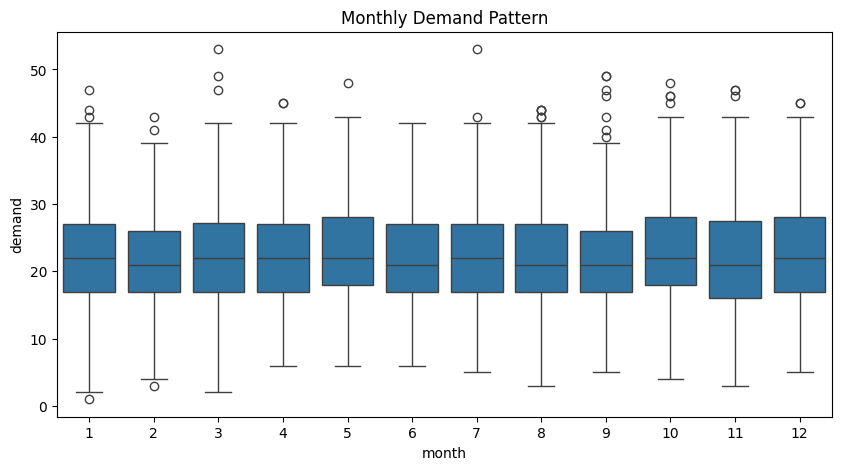

In [13]:
real_df['month'] = real_df['date'].dt.month

plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='demand', data=real_df)
plt.title("Monthly Demand Pattern")
plt.show()

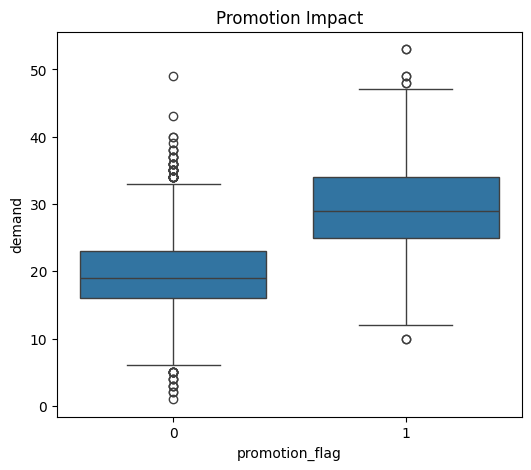

In [14]:
if 'promotion_flag' in real_df.columns:
    plt.figure(figsize=(6,5))
    sns.boxplot(x='promotion_flag', y='demand', data=real_df)
    plt.title("Promotion Impact")
    plt.show()

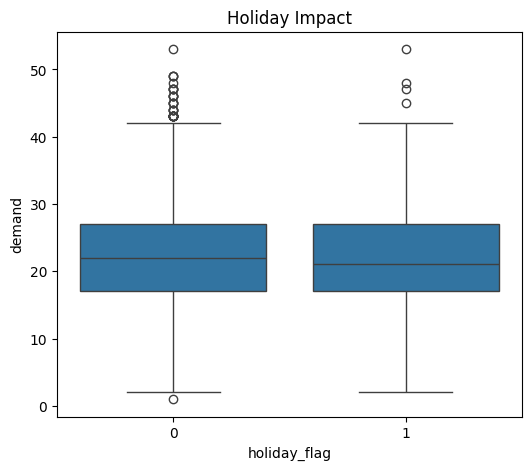

In [15]:
if 'holiday_flag' in real_df.columns:
    plt.figure(figsize=(6,5))
    sns.boxplot(x='holiday_flag', y='demand', data=real_df)
    plt.title("Holiday Impact")
    plt.show()

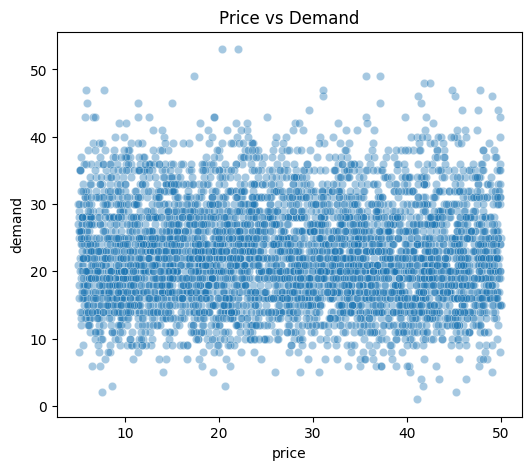

In [16]:
if 'price' in real_df.columns:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x='price', y='demand', data=real_df, alpha=0.4)
    plt.title("Price vs Demand")
    plt.show()

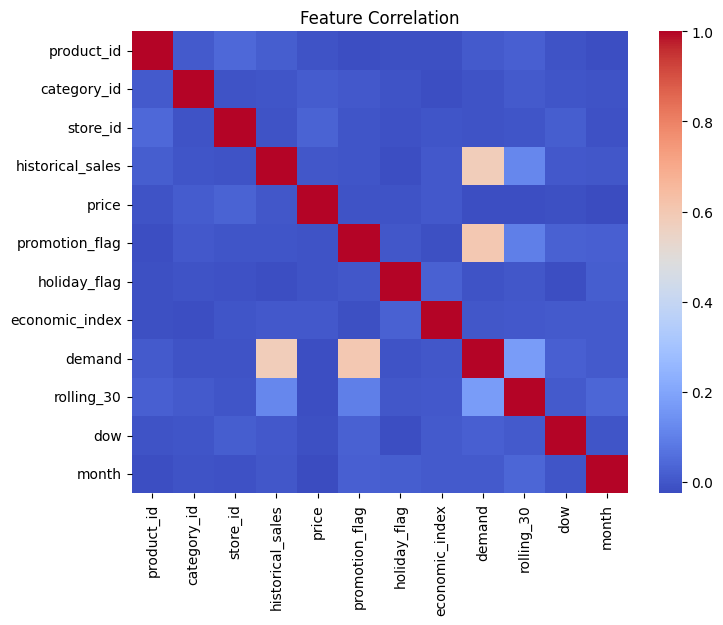

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(real_df.corr(numeric_only=True),
            annot=False,
            cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

**SYNTHETIC DATA**

In [18]:
NUM_STORES = 5
NUM_PRODUCTS = 30
DAYS = 365 * 2

START_DATE = datetime(2023, 1, 1)

In [19]:
def is_festival(date):

    festivals = [
        (1, 1),    # New Year
        (1, 26),   # Republic Day
        (3, 8),    # Holi
        (8, 15),   # Independence Day
        (10, 20),  # Diwali
        (10, 21),  # Diwali
        (10, 22),  # Diwali
        (12, 25)   # Christmas
    ]

    return (date.month, date.day) in festivals

In [20]:
data = []

MAX_CAPACITY = np.random.randint(55, 70)

for s in range(1, NUM_STORES + 1):

    for p in range(1, NUM_PRODUCTS + 1):

        base = np.random.normal(22, 5)
        base = max(10, base)

        base_price = random.uniform(35, 55)

        for d in range(DAYS):

            date = START_DATE + timedelta(days=d)

            trend = 0.003 * d

            season = random.uniform(1.5, 3.5) * np.sin(2 * np.pi * d / 7)

            noise = np.random.normal(0, 7)

            demand = base + trend + season + noise

            promotion = random.random() < 0.2
            shock = "none"

            if promotion:
                promo_mult = random.uniform(1.05,1.4)
                demand *= promo_mult
                shock = "promotion"

            holiday = is_festival(date)

            if holiday:
                fest_mult = np.random.uniform(1.4, 1.8)
                demand *= fest_mult
                shock = "festival"

            bad_event = random.random() < 0.08

            if bad_event:
                neg_mult = np.random.uniform(0.7, 1.1)
                demand *= neg_mult
                shock = "negative_event"

            if np.random.rand() < 0.03:
                noise += np.random.normal(0, 9)

            demand = min(demand, MAX_CAPACITY)

            demand = max(0, int(demand))

            price = base_price + np.random.normal(0, 1.2)

            price = max(12, round(price, 2))

            elasticity = np.random.uniform(0.1, 0.25)

            price_effect = 1 - elasticity * ((price - base_price) / base_price)

            demand *= max(0.7, price_effect)

            data.append([
                date.strftime("%Y-%m-%d"),
                f"S{s}",
                f"P{p}",
                price,
                int(promotion),
                int(holiday),
                demand,
                shock
            ])


In [21]:
syn_df = pd.DataFrame(
    data,
    columns=[
        "date",
        "store_id",
        "product_id",
        "price",
        "promotion",
        "holiday",
        "demand",
        "shock_label"
    ]
)

In [22]:
syn_df.to_csv("synthetic_supply_chain_data.csv", index=False)

In [23]:
syn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109500 entries, 0 to 109499
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         109500 non-null  object 
 1   store_id     109500 non-null  object 
 2   product_id   109500 non-null  object 
 3   price        109500 non-null  float64
 4   promotion    109500 non-null  int64  
 5   holiday      109500 non-null  int64  
 6   demand       109500 non-null  float64
 7   shock_label  109500 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 6.7+ MB


In [24]:
syn_df.head()

,date,store_id,product_id,price,promotion,holiday,demand,shock_label
0,2023-01-01,S1,P1,44.48,0,1,37.245921,festival
1,2023-01-02,S1,P1,44.49,1,0,25.090977,negative_event
2,2023-01-03,S1,P1,47.49,0,0,24.817078,negative_event
3,2023-01-04,S1,P1,46.56,0,0,19.941919,none
4,2023-01-05,S1,P1,46.27,0,0,21.981283,none


In [25]:
syn_df['price'].describe()

,price
count,109500.000000
mean,45.673018
std,5.753330
min,31.530000
25%,40.910000
50%,45.630000
75%,50.702500
max,59.050000


In [26]:
syn_df['holiday'].value_counts()

,count
holiday,
0,107100
1,2400


In [27]:
syn_df["shock_label"].value_counts()

,count
shock_label,
none,78677
promotion,19835
negative_event,8779
festival,2209


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

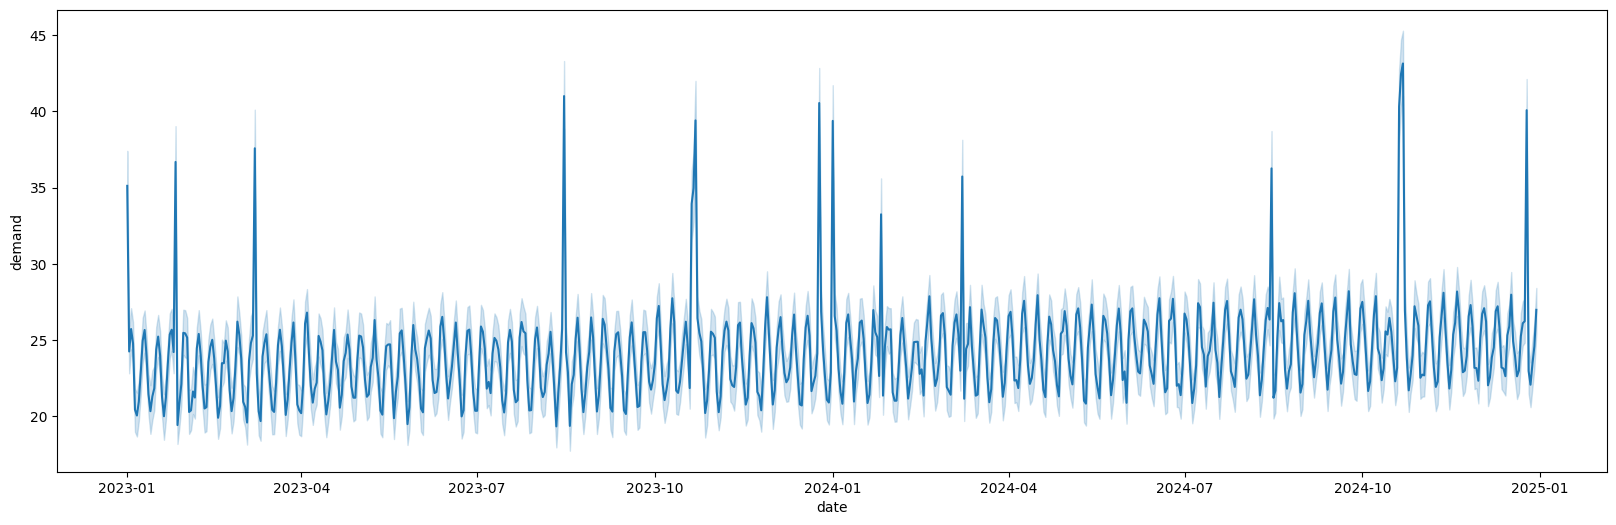

In [29]:
syn_df['date'] = pd.to_datetime(syn_df['date'])

plt.figure(figsize=(20, 6))

sns.lineplot(x='date', y='demand', data=syn_df)
plt.show()

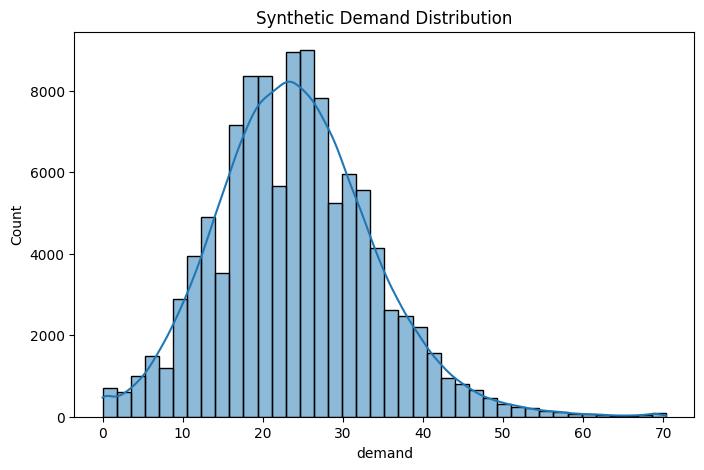

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(syn_df['demand'], bins=40, kde=True)
plt.title("Synthetic Demand Distribution")
plt.show()

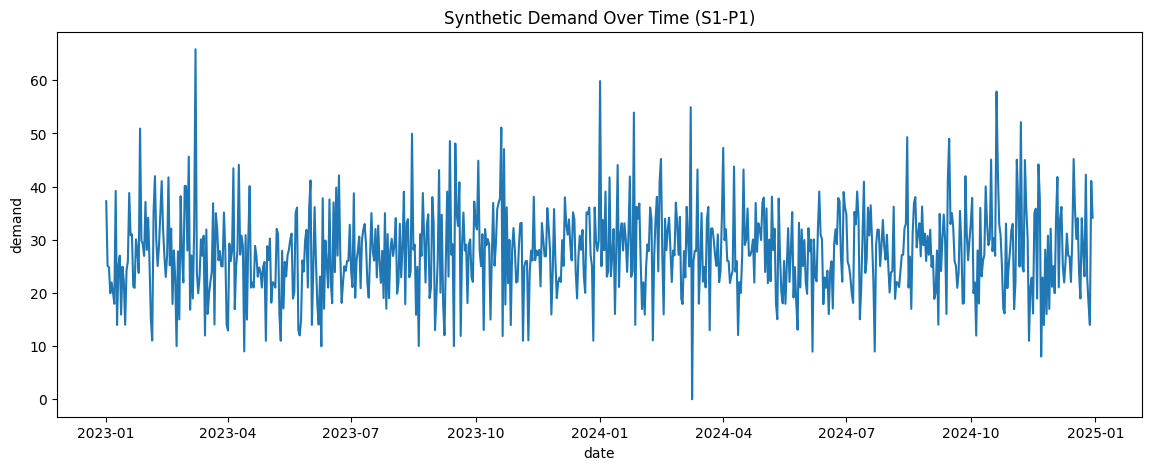

In [31]:
sample_syn = syn_df[
    (syn_df['store_id'] == 'S1') &
    (syn_df['product_id'] == 'P1')
]

plt.figure(figsize=(14,5))
sns.lineplot(x='date', y='demand', data=sample_syn)
plt.title("Synthetic Demand Over Time (S1-P1)")
plt.show()

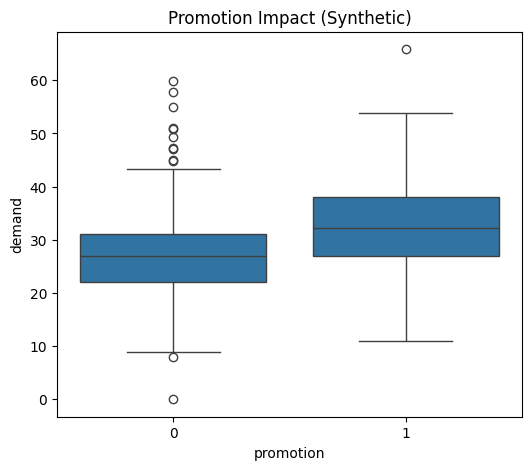

In [32]:
plt.figure(figsize=(6,5))
sns.boxplot(x='promotion', y='demand', data=sample_syn)
plt.title("Promotion Impact (Synthetic)")
plt.show()

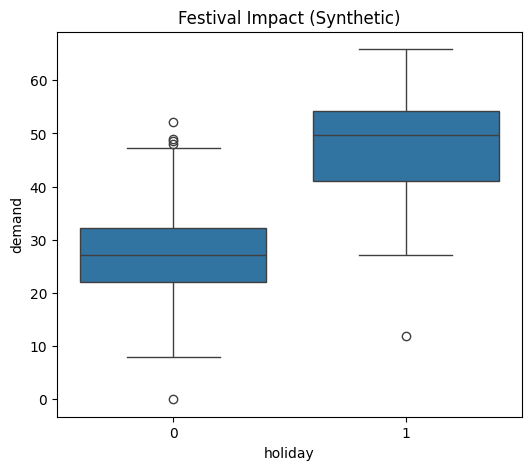

In [33]:
plt.figure(figsize=(6,5))
sns.boxplot(x='holiday', y='demand', data=sample_syn)
plt.title("Festival Impact (Synthetic)")
plt.show()

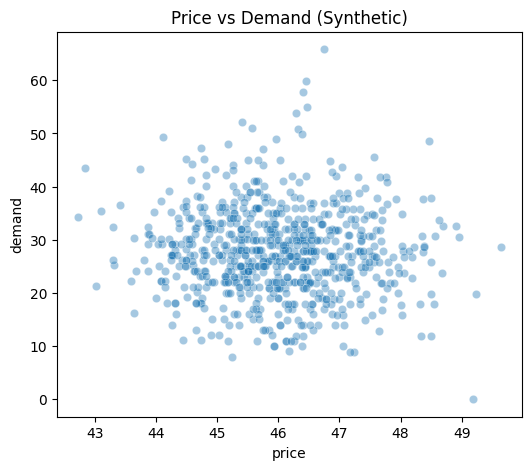

In [34]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='price', y='demand',
                data=sample_syn,
                alpha=0.4)
plt.title("Price vs Demand (Synthetic)")
plt.show()

/tmp/ipykernel_2611/3732775644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_syn['dow'] = sample_syn['date'].dt.dayofweek


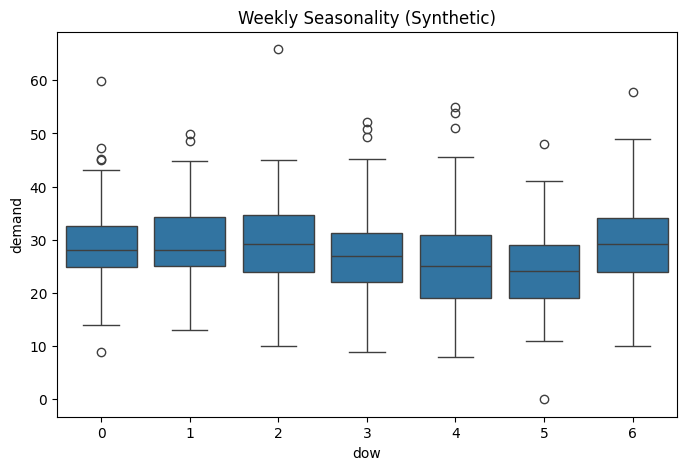

In [35]:
sample_syn['dow'] = sample_syn['date'].dt.dayofweek

plt.figure(figsize=(8,5))
sns.boxplot(x='dow', y='demand', data=sample_syn)
plt.title("Weekly Seasonality (Synthetic)")
plt.show()

/tmp/ipykernel_2611/4237000553.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_syn['month'] = sample_syn['date'].dt.month


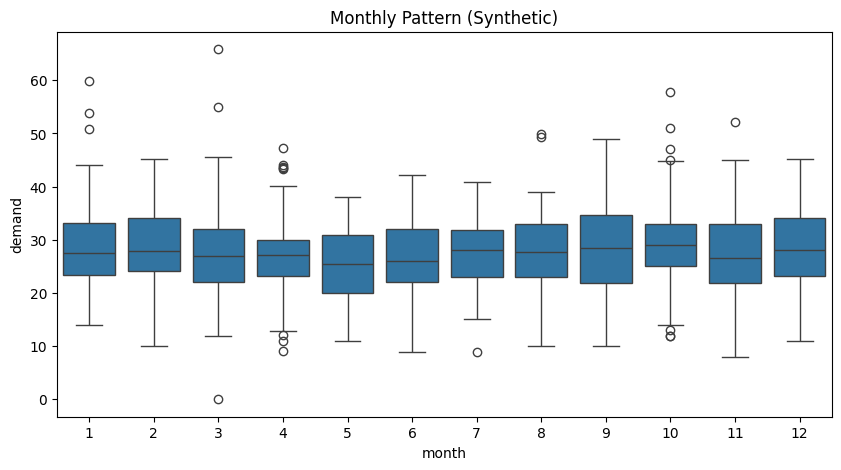

In [36]:
sample_syn['month'] = sample_syn['date'].dt.month

plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='demand', data=sample_syn)
plt.title("Monthly Pattern (Synthetic)")
plt.show()

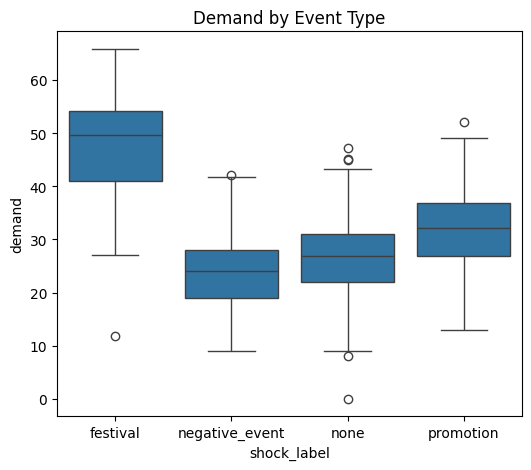

In [37]:
if 'shock_label' in syn_df.columns:
    plt.figure(figsize=(6,5))
    sns.boxplot(x='shock_label', y='demand', data=sample_syn)
    plt.title("Demand by Event Type")
    plt.show()

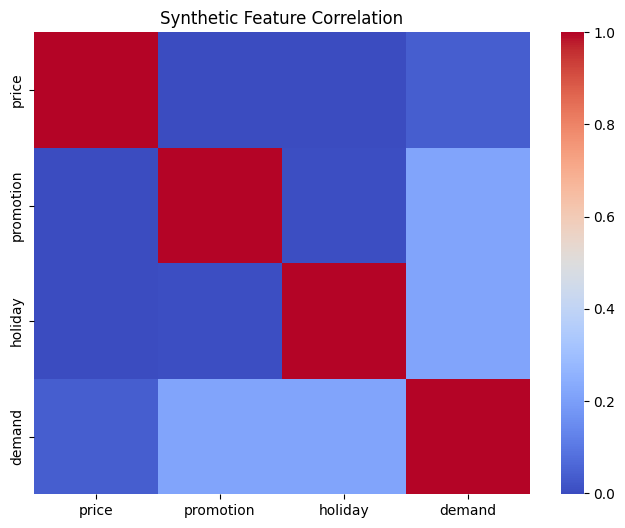

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(
    syn_df.corr(numeric_only=True),
    annot=False,
    cmap='coolwarm'
)
plt.title("Synthetic Feature Correlation")
plt.show()

**COMPARING REAL AND SYNTHETIC DATA**


In [39]:
real_df['date'] = pd.to_datetime(real_df['date'])
syn_df['date'] = pd.to_datetime(syn_df['date'])

real_df['source'] = 'Real'
syn_df['source'] = 'Synthetic'

combined = pd.concat([real_df, syn_df])

In [40]:
stats = pd.DataFrame({
    "Real": real_df['demand'].describe(),
    "Synthetic": syn_df['demand'].describe()
})

stats

,Real,Synthetic
count,4921.000000,109500.000000
mean,22.421459,24.117507
std,7.489883,9.820279
min,1.000000,0.000000
25%,17.000000,17.203045
50%,22.000000,23.886218
75%,27.000000,30.031709
max,53.000000,70.358619


In [41]:
real_sample = real_df.iloc[:1000]

syn_sample = syn_df[
    (syn_df['store_id']=='S1') &
    (syn_df['product_id']=='P1')
].iloc[:1000]

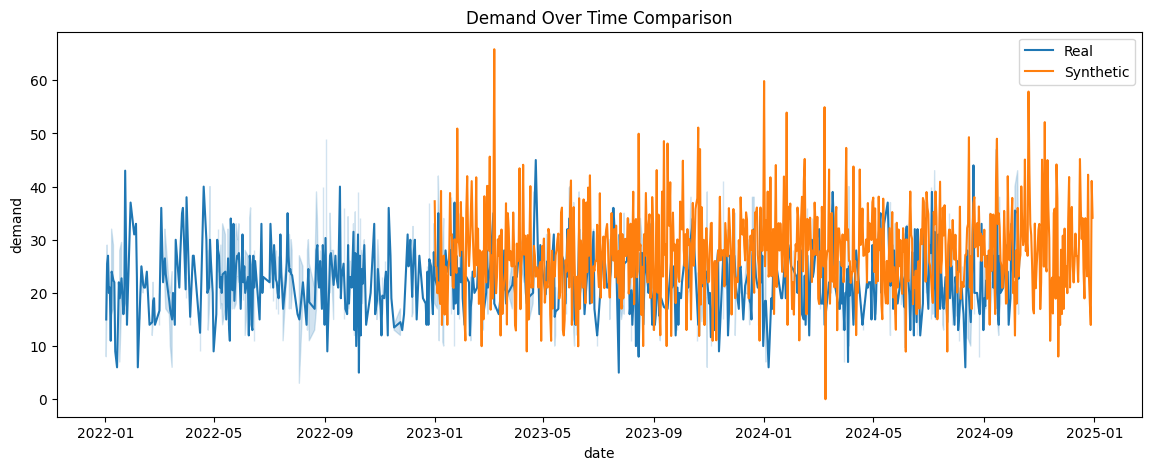

In [42]:
plt.figure(figsize=(14,5))

sns.lineplot(x='date', y='demand', data=real_sample, label='Real')
sns.lineplot(x='date', y='demand', data=syn_sample, label='Synthetic')

plt.title("Demand Over Time Comparison")
plt.show()

In [43]:
for df in [real_df, syn_df]:
    df['month'] = df['date'].dt.month

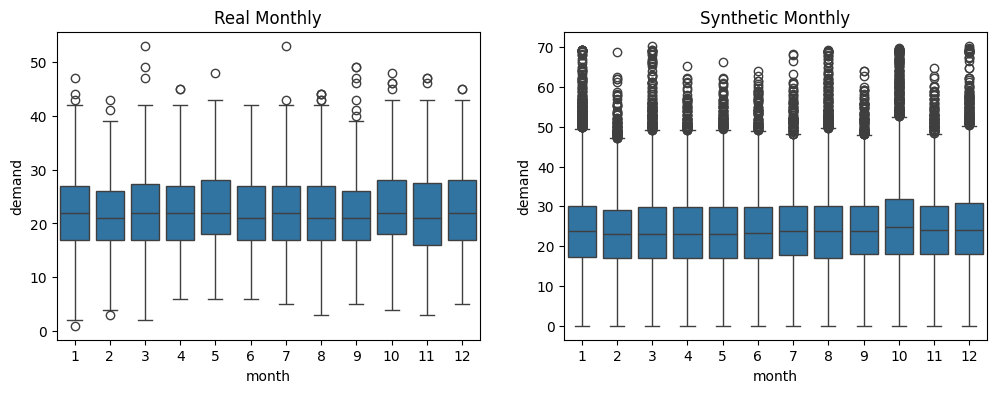

In [44]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x='month', y='demand', data=real_df)
plt.title("Real Monthly")

plt.subplot(1,2,2)
sns.boxplot(x='month', y='demand', data=syn_df)
plt.title("Synthetic Monthly")

plt.show()

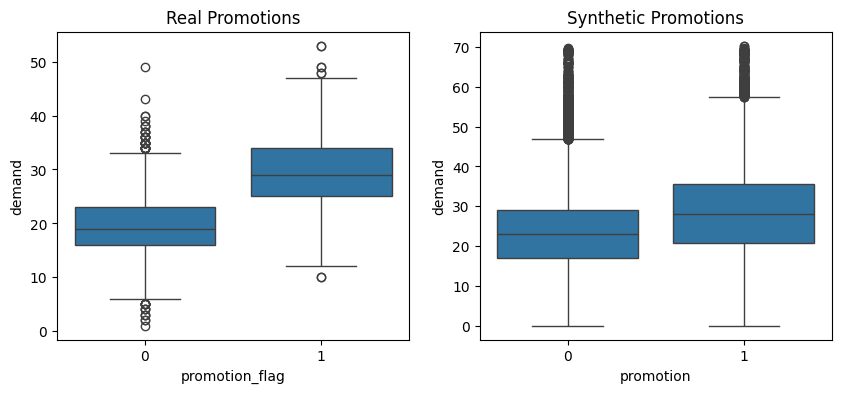

In [45]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x='promotion_flag', y='demand', data=real_df)
plt.title("Real Promotions")

plt.subplot(1,2,2)
sns.boxplot(x='promotion', y='demand', data=syn_df)
plt.title("Synthetic Promotions")

plt.show()

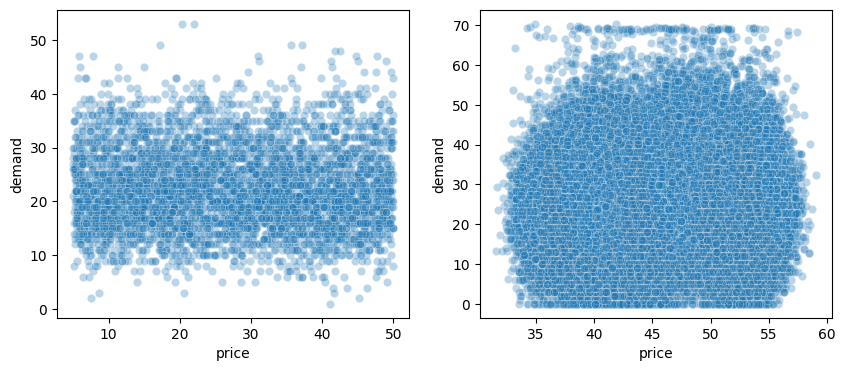

In [46]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.scatterplot(x='price', y='demand', data=real_df, alpha=0.3)

plt.subplot(1,2,2)
sns.scatterplot(x='price', y='demand', data=syn_df, alpha=0.3)

plt.show()

**PREPROCESSING**

In [47]:
real_df.head()

,date,product_id,category_id,store_id,historical_sales,price,promotion_flag,holiday_flag,economic_index,demand,rolling_30,dow,month,source
0,2022-01-02,1043,4,9,16,48.29,0,0,84.07,8,NaN,6,1,Real
1,2022-01-02,1012,4,2,25,44.01,0,0,106.87,22,NaN,6,1,Real
2,2022-01-03,1003,5,4,26,9.44,1,0,104.98,29,NaN,0,1,Real
3,2022-01-03,1005,4,1,23,5.42,1,1,92.75,22,NaN,0,1,Real
4,2022-01-04,1011,1,5,12,21.86,1,1,103.60,27,NaN,1,1,Real


In [48]:
syn_df.head()

,date,store_id,product_id,price,promotion,holiday,demand,shock_label,source,month
0,2023-01-01,S1,P1,44.48,0,1,37.245921,festival,Synthetic,1
1,2023-01-02,S1,P1,44.49,1,0,25.090977,negative_event,Synthetic,1
2,2023-01-03,S1,P1,47.49,0,0,24.817078,negative_event,Synthetic,1
3,2023-01-04,S1,P1,46.56,0,0,19.941919,none,Synthetic,1
4,2023-01-05,S1,P1,46.27,0,0,21.981283,none,Synthetic,1


In [49]:
syn_df.rename(columns={
    'promotion': 'promotion_flag',
    'holiday': 'holiday_flag'
}, inplace=True)

In [50]:
syn_df['dow'] = syn_df['date'].dt.dayofweek

In [51]:
features = [
    'product_id',
    'store_id',
    'price',
    'promotion_flag',
    'holiday_flag',
    'dow',
    'month'
]

target = 'demand'

real_aligned = real_df[features + [target]].copy()
syn_aligned = syn_df[features + [target]].copy()

In [52]:
real_aligned.head()

,product_id,store_id,price,promotion_flag,holiday_flag,dow,month,demand
0,1043,9,48.29,0,0,6,1,8
1,1012,2,44.01,0,0,6,1,22
2,1003,4,9.44,1,0,0,1,29
3,1005,1,5.42,1,1,0,1,22
4,1011,5,21.86,1,1,1,1,27


In [53]:
syn_aligned.head()

,product_id,store_id,price,promotion_flag,holiday_flag,dow,month,demand
0,P1,S1,44.48,0,1,6,1,37.245921
1,P1,S1,44.49,1,0,0,1,25.090977
2,P1,S1,47.49,0,0,1,1,24.817078
3,P1,S1,46.56,0,0,2,1,19.941919
4,P1,S1,46.27,0,0,3,1,21.981283


In [54]:
syn_aligned = syn_aligned.drop(['product_id','store_id'], axis=1)
real_aligned = real_aligned.drop(['product_id','store_id'], axis=1)

In [55]:
syn_aligned.head()

,price,promotion_flag,holiday_flag,dow,month,demand
0,44.48,0,1,6,1,37.245921
1,44.49,1,0,0,1,25.090977
2,47.49,0,0,1,1,24.817078
3,46.56,0,0,2,1,19.941919
4,46.27,0,0,3,1,21.981283


In [56]:
real_aligned.head()

,price,promotion_flag,holiday_flag,dow,month,demand
0,48.29,0,0,6,1,8
1,44.01,0,0,6,1,22
2,9.44,1,0,0,1,29
3,5.42,1,1,0,1,22
4,21.86,1,1,1,1,27


In [57]:

syn_aligned['rolling_7'] = syn_aligned['demand'].rolling(7).mean()

In [58]:

real_aligned['rolling_7'] = real_aligned['demand'].rolling(7).mean()

In [59]:
syn_aligned.dropna(inplace=True)
real_aligned.dropna(inplace=True)

In [60]:
syn_aligned.head()

,price,promotion_flag,holiday_flag,dow,month,demand,rolling_7
6,47.18,1,0,5,1,17.948413,23.874800
7,44.21,0,0,6,1,39.181130,24.151259
8,46.64,0,0,0,1,13.970122,22.562565
9,46.44,0,0,1,1,24.963341,22.583460
10,45.95,0,0,2,1,27.006077,23.592625


In [61]:
real_aligned.head()

,price,promotion_flag,holiday_flag,dow,month,demand,rolling_7
6,21.57,0,0,3,1,21,21.285714
7,18.80,0,0,4,1,11,21.714286
8,7.78,1,1,5,1,32,23.142857
9,33.30,0,0,5,1,16,21.285714
10,37.12,1,0,0,1,29,22.285714


In [62]:
syn_aligned['lag_1'] = syn_aligned['demand'].shift(1)
syn_aligned['lag_7'] = syn_aligned['demand'].shift(7)

real_aligned['lag_1'] = real_aligned['demand'].shift(1)
real_aligned['lag_7'] = real_aligned['demand'].shift(7)

In [63]:
syn_aligned['rolling_14'] = syn_aligned['demand'].rolling(14).mean()
real_aligned['rolling_14'] = real_aligned['demand'].rolling(14).mean()

syn_aligned = syn_aligned.dropna()
real_aligned = real_aligned.dropna()

In [64]:
X_syn = syn_aligned.drop('demand', axis=1)
y_syn = syn_aligned['demand']

X_real = real_aligned.drop('demand', axis=1)
y_real = real_aligned['demand']

In [65]:
split_index = int(len(X_syn) * 0.8)

X_syn_train = X_syn.iloc[:split_index]
X_syn_test  = X_syn.iloc[split_index:]

y_syn_train = y_syn.iloc[:split_index]
y_syn_test  = y_syn.iloc[split_index:]

In [66]:
from sklearn.preprocessing import StandardScaler

In [67]:
scaler = StandardScaler()

X_syn_train_scaled = scaler.fit_transform(X_syn_train)
X_syn_test_scaled  = scaler.transform(X_syn_test)

X_real_scaled = scaler.transform(X_real)

**GRADIENT BOOSTING REGRESSION**

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [69]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(X_syn_train_scaled, y_syn_train)

GradientBoostingRegressor()

In [70]:
syn_pred = model.predict(X_syn_test_scaled)

In [71]:
print("Synthetic Test RMSE:", np.sqrt(mean_squared_error(y_syn_test, syn_pred)))
print("Synthetic Test MAE:", np.sqrt(mean_absolute_error(y_syn_test, syn_pred)))

Synthetic Test RMSE: 6.923199390770507
Synthetic Test MAE: 2.343219213607


In [72]:
real_pred = model.predict(X_real_scaled)

In [73]:
print("Real RMSE:", np.sqrt(mean_squared_error(y_real, real_pred)))
print("Real MAE:", np.sqrt(mean_absolute_error(y_real, real_pred)))

Real RMSE: 7.506400404695704
Real MAE: 2.4196195553377846


In [74]:
baseline_pred = np.repeat(y_real.mean(), len(y_real))
baseline_rmse = np.sqrt(mean_squared_error(y_real, baseline_pred))
print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 7.484006376255455


In [75]:
print(syn_aligned.corr()['demand'])
print(real_aligned.corr()['demand'])

price             0.040002
promotion_flag    0.214885
holiday_flag      0.213383
dow              -0.140906
month             0.034045
demand            1.000000
rolling_7         0.609638
lag_1             0.311694
lag_7             0.311495
rolling_14        0.565202
Name: demand, dtype: float64
price            -0.020250
promotion_flag    0.600709
holiday_flag     -0.010030
dow               0.021432
month             0.006878
demand            1.000000
rolling_7         0.367635
lag_1             0.000954
lag_7             0.004377
rolling_14        0.245595
Name: demand, dtype: float64


**RANDOM FOREST**

In [76]:
from sklearn.ensemble import RandomForestRegressor

In [77]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [78]:
rf.fit(X_syn_train_scaled, y_syn_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [79]:
syn_pred = rf.predict(X_syn_test_scaled)
real_pred = rf.predict(X_real_scaled)

In [80]:
print("Synthetic RMSE:", np.sqrt(mean_squared_error(y_syn_test, syn_pred)))
print("Real RMSE:", np.sqrt(mean_squared_error(y_real, real_pred)))
print("Synthetic Test MAE:", np.sqrt(mean_absolute_error(y_syn_test, syn_pred)))
print("Real MAE:", np.sqrt(mean_absolute_error(y_real, real_pred)))

Synthetic RMSE: 6.968905937615223
Real RMSE: 7.627858126765228
Synthetic Test MAE: 2.350714599896729
Real MAE: 2.4347253472369954


In [81]:
syn_aligned['demand'].mean()

np.float64(24.117409373129483)

In [82]:
real_aligned['demand'].mean()

np.float64(22.431864545083638)

In [83]:
#i am getting a 10% MAE on both real and synthetic datasets which means these models aren't strong enough to capture patterns as data is quite non linear but synthetic and real data is behaving similarly

**PREPROCESSING FOR LSTM**

In [84]:
syn_lstm = syn_aligned.drop('lag_1',axis = 1)
syn_lstm = syn_aligned.drop('lag_7',axis = 1)

In [85]:
syn_lstm.head()

,price,promotion_flag,holiday_flag,dow,month,demand,rolling_7,lag_1,rolling_14
19,45.95,0,0,4,1,31.006264,26.696510,30.852943,25.056752
20,44.45,0,0,5,1,21.175377,26.561569,31.006264,25.287249
21,46.76,0,0,6,1,20.948819,27.554541,21.175377,23.984941
22,45.35,0,0,0,1,30.081222,28.397013,20.948819,25.135734
23,47.32,0,0,1,1,27.915424,28.682240,30.081222,25.346597


In [86]:
real_lstm = real_aligned.drop('lag_1',axis = 1)
real_lstm = real_aligned.drop('lag_7',axis = 1)

In [87]:
real_lstm.head()

,price,promotion_flag,holiday_flag,dow,month,demand,rolling_7,lag_1,rolling_14
19,11.25,0,0,0,1,16,16.571429,7.0,18.785714
20,41.69,1,0,2,1,31,17.857143,16.0,19.500000
21,40.74,0,0,2,1,16,18.857143,31.0,19.857143
22,44.73,0,0,2,1,25,21.571429,16.0,19.357143
23,26.83,0,0,2,1,19,21.142857,25.0,19.571429


In [88]:
features = [
    "price",
    "promotion_flag",
    "holiday_flag",
    "dow",
    "month",
    "rolling_7",
    "rolling_14"
]

target = "demand"

In [89]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

syn_scaled = scaler.fit_transform(syn_lstm[features + [target]])
real_scaled = scaler.transform(real_lstm[features + [target]])

In [90]:
import numpy as np

def create_sequences(data, seq_len, target_index):

    X = []
    y = []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :-1])
        y.append(data[i+seq_len, target_index])

    return np.array(X), np.array(y)

In [91]:
SEQ_LEN = 30
target_index = len(features)

X_syn, y_syn = create_sequences(syn_scaled, SEQ_LEN, target_index)
X_real, y_real = create_sequences(real_scaled, SEQ_LEN, target_index)

In [92]:
split = int(len(X_syn)*0.8)

X_train = X_syn[:split]
y_train = y_syn[:split]

X_val = X_syn[split:]
y_val = y_syn[split:]

**LSTM**

In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [94]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [95]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [96]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 0.0168 - mae: 0.1001 - val_loss: 0.0141 - val_mae: 0.0918
Epoch 2/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0144 - mae: 0.0933 - val_loss: 0.0136 - val_mae: 0.0911
Epoch 3/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0142 - mae: 0.0926 - val_loss: 0.0136 - val_mae: 0.0910
Epoch 4/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0142 - mae: 0.0926 - val_loss: 0.0137 - val_mae: 0.0909
Epoch 5/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0140 - mae: 0.0921 - val_loss: 0.0134 - val_mae: 0.0903
Epoch 6/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0139 - mae: 0.0917 - val_loss: 0.0137 - val_mae: 0.0920
Epoch 7/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0140 - mae: 0.0921 - val_loss: 0.0135 - val_mae: 0.0904
Epoch 8/50
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0141 - mae: 0.0924 - val_loss: 0.0137 - val_mae: 0.0920
Epoch 9/50
2737/2737 ━━━━━━━━━━━

In [97]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,181 (367.90 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,788 (245.27 KB)

In [98]:
real_preds = model.predict(X_real)

153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [99]:
from sklearn.metrics import mean_absolute_error

mae_real = mean_absolute_error(y_real, real_preds)

print("Real MAE:", mae_real)

Real MAE: 0.09560391006295296


In [100]:
real_lstm["demand"].min(), real_lstm["demand"].max(), real_lstm["demand"].mean()

(1, 53, np.float64(22.431864545083638))

In [101]:
#The mae of lstm is 0.106 but this is not actually low since we have scaled the x and y data so the prediction gets an error of 0.1 which is actually 0.1 * 53 which is 5.3 mae

**RESULTS**

In [102]:
import pandas as pd

results = {
    "Model": ["Linear Regression", "Random Forest", "LSTM"],
    "Dataset": ["Real", "Real", "Real"],
    "MAE": [2.42, 2.43, 5.30]
}

results_df = pd.DataFrame(results)
results_df

,Model,Dataset,MAE
0,Linear Regression,Real,2.42
1,Random Forest,Real,2.43
2,LSTM,Real,5.30


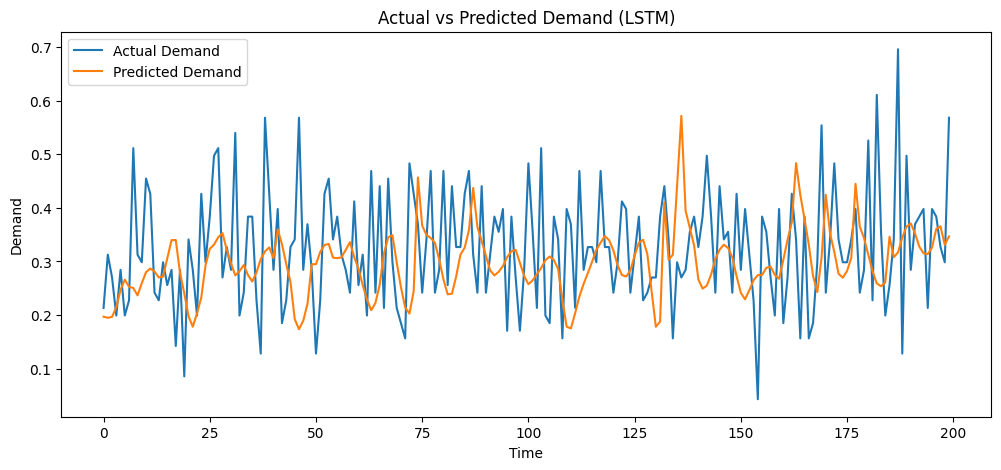

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_real[:200], label="Actual Demand")
plt.plot(real_preds[:200], label="Predicted Demand")
plt.legend()
plt.title("Actual vs Predicted Demand (LSTM)")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()

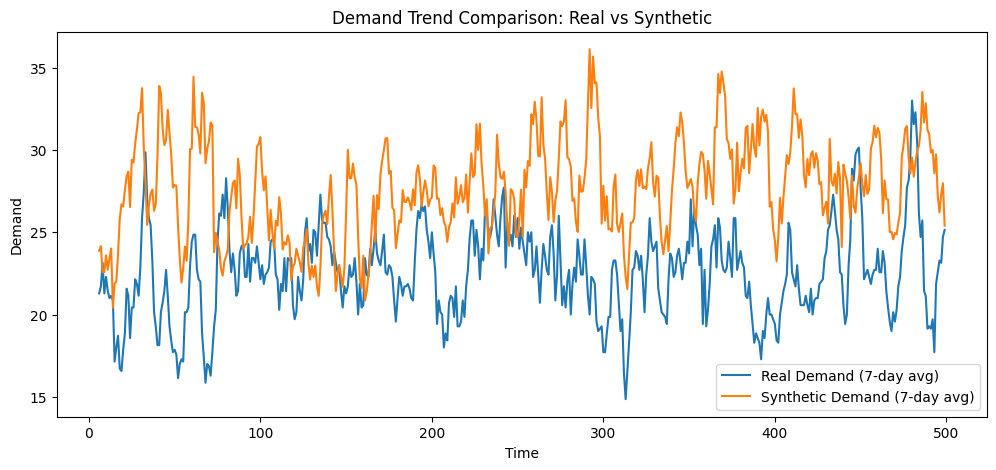

In [104]:
import matplotlib.pyplot as plt

real_roll = real_df["demand"].rolling(7).mean()
syn_roll = syn_df["demand"].rolling(7).mean()

plt.figure(figsize=(12,5))

plt.plot(real_roll[:500], label="Real Demand (7-day avg)")
plt.plot(syn_roll[:500], label="Synthetic Demand (7-day avg)")

plt.title("Demand Trend Comparison: Real vs Synthetic")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()

plt.show()